In [1]:
import numpy as np
from stable_baselines3 import PPO
from QuantumRepeater import QuantumRepeaterEnv
from MemoryCutoffPolicy import baseline_policy
import matplotlib.pyplot as plt

# **Comparing DRL agent and Memory-cutoff Baseline Policy**

In [6]:
def evaluate_policy(env, policy, episodes):
    episode_rewards = []
    success_counts = []
    link_ages = []
    
    time_for_entanglement = []
    skr = []

    for seed in range(episodes):
        obs, _ = env.reset(seed=seed)
        total_reward = 0
        successes = 0

        for _ in range(env.max_steps):
            action = policy(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

            if "Link Age" in info:
                successes += 1
                link_ages.append(info["Link Age"])
                time_for_entanglement.append(info["Time"])
                skr.append(info["SKR"])
        
        print(f"Episode {seed + 1}/{episodes} - Total Reward: {total_reward:.2f}, Successes: {successes}")
        
        episode_rewards.append(total_reward)
        success_counts.append(successes)
    return episode_rewards, success_counts, link_ages, time_for_entanglement, skr

## **Evaluating DRL Agent**

In [7]:
model = PPO.load("quantum_repeater_agent")

def PPO_policy(obs):
    action, _ = model.predict(obs, deterministic=True)
    return action

In [8]:
episodes = 50

env = QuantumRepeaterEnv(
    n_segments=4,
    tau_c=10.0,
    normalized=True
)

In [9]:
agent_episode_rewards, agent_success_counts, agent_link_ages, agent_time_for_entanglement, agent_skr = evaluate_policy(env, baseline_policy, episodes)

print("PPO Agent")
print(f"Mean episode reward: {np.mean(agent_episode_rewards):.2f} ± {np.std(agent_episode_rewards):.2f}")
print(f"Mean successes per episode: {np.mean(agent_success_counts):.2f}")
if agent_link_ages:
    print(f"Mean end-to-end link age: {np.mean(agent_link_ages):.2f}")
else:
    print("No successful end-to-end entanglements observed.")

Episode 1/50 - Total Reward: 3337.83, Successes: 5054
Episode 2/50 - Total Reward: 4034.45, Successes: 5136
Episode 3/50 - Total Reward: 3951.13, Successes: 5058
Episode 4/50 - Total Reward: 4127.19, Successes: 5156
Episode 5/50 - Total Reward: 4470.78, Successes: 5174
Episode 6/50 - Total Reward: 3870.80, Successes: 5150
Episode 7/50 - Total Reward: 4051.13, Successes: 5121
Episode 8/50 - Total Reward: 3174.91, Successes: 5054
Episode 9/50 - Total Reward: 3936.65, Successes: 5160
Episode 10/50 - Total Reward: 4359.92, Successes: 5179
Episode 11/50 - Total Reward: 4165.57, Successes: 5134
Episode 12/50 - Total Reward: 3965.55, Successes: 5092
Episode 13/50 - Total Reward: 4123.06, Successes: 5103
Episode 14/50 - Total Reward: 4178.45, Successes: 5128
Episode 15/50 - Total Reward: 3791.57, Successes: 5090
Episode 16/50 - Total Reward: 4391.86, Successes: 5151
Episode 17/50 - Total Reward: 2777.58, Successes: 5030
Episode 18/50 - Total Reward: 3757.68, Successes: 5154
Episode 19/50 - Tot

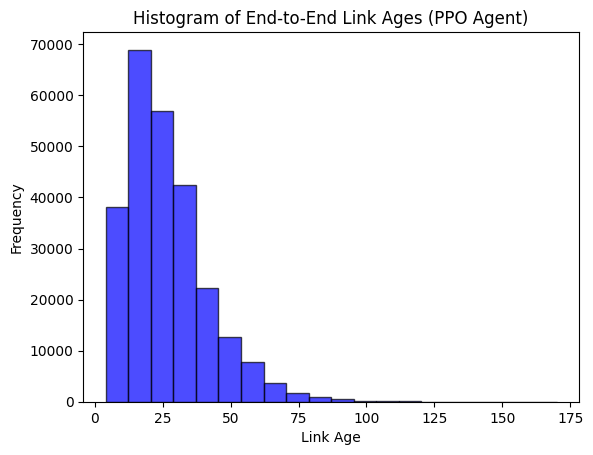

In [10]:
plt.hist(agent_link_ages, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of End-to-End Link Ages (PPO Agent)')
plt.xlabel('Link Age')
plt.ylabel('Frequency')
plt.show()

(array([1.66069e+05, 2.63660e+04, 1.74520e+04, 1.61910e+04, 7.29900e+03,
        6.63100e+03, 5.50600e+03, 0.00000e+00, 4.55000e+03, 0.00000e+00,
        3.33100e+03, 0.00000e+00, 1.97500e+03, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 8.75000e+02, 0.00000e+00, 0.00000e+00, 1.34000e+02]),
 array([0.        , 0.01771182, 0.03542364, 0.05313545, 0.07084727,
        0.08855909, 0.10627091, 0.12398273, 0.14169455, 0.15940636,
        0.17711818, 0.19483   , 0.21254182, 0.23025364, 0.24796546,
        0.26567727, 0.28338909, 0.30110091, 0.31881273, 0.33652455,
        0.35423636]),
 <BarContainer object of 20 artists>)

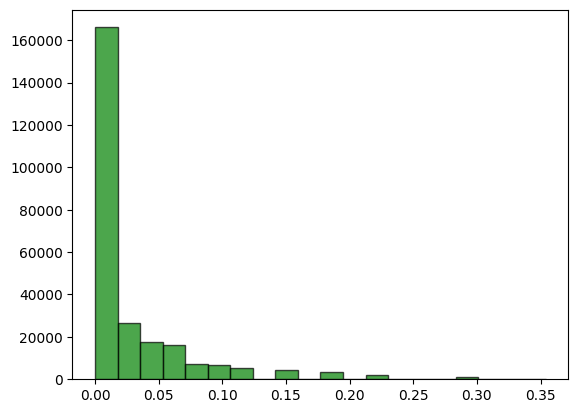

In [12]:
plt.hist(agent_skr, bins=20, alpha=0.7, color='green', edgecolor='black')

## **Evaluating Memory-cutoff Baseline Policy**

In [ ]:
episodes = 50

env = QuantumRepeaterEnv(
    n_segments=4,
    tau_c=10.0,
    normalized=False
)

In [ ]:
baseline_episode_rewards, baseline_success_counts, baseline_link_ages, baseline_time_for_entanglement, baseline_skr = evaluate_policy(env, baseline_policy, episodes)

print("Memory-Cutoff Baseline")
print(f"Mean episode reward: {np.mean(baseline_episode_rewards):.2f} ± {np.std(baseline_episode_rewards):.2f}")
print(f"Mean successes per episode: {np.mean(baseline_success_counts):.2f}")
if baseline_link_ages:
    print(f"Mean end-to-end link age: {np.mean(baseline_link_ages):.2f}")
else:
    print("No successful end-to-end entanglements observed.")

In [ ]:
plt.hist(baseline_link_ages, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of End-to-End Link Ages (Memory-Cutoff Baseline)')
plt.xlabel('Link Age')
plt.ylabel('Frequency')
plt.show()